In [ ]:
import subprocess

from typing import List, TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph import StateGraph, END


In [6]:
def get_github_token() -> str | None:
    """Возвращает персональный токен GitHub, используя GitHub CLI.

    Вместо того чтобы хранить токен в коде или переменных окружения,
    мы делегируем его получение инструменту ``gh`` (GitHub CLI).
    Это безопасно: токен никогда не попадает в файлы проекта.

    Returns:
        Строка с токеном если GitHub CLI установлен и пользователь
        аутентифицирован (``gh auth login``), иначе ``None``.

    Raises:
        Не бросает исключений — все ошибки перехватываются внутри.
    """
    try:
        token = subprocess.check_output(["gh", "auth", "token"]).decode("utf-8").strip()
        return token
    except Exception as e:
        print("Ошибка: Убедитесь, что GitHub CLI установлен и вы залогинены (gh auth login)")
        return None


In [7]:
# =============================================================================
# Инициализация LLM
# -----------------------------------------------------------------------------
# Используем ChatOpenAI из LangChain, но направляем запросы НЕ в OpenAI,
# а в GitHub Models (Azure inference endpoint).
# GitHub Models поддерживает OpenAI-совместимый API → меняем только base_url.
#
# Параметры:
#   model       — имя модели на GitHub Models (Llama 3.3 70B)
#   temperature — чем ниже, тем детерминированнее ответы (0 = почти точные,
#                  1 = творческие); 0.2 хорошо подходит для ассистента
#   base_url    — эндпоинт GitHub Models (вместо api.openai.com)
#   api_key     — GitHub-токен, полученный из CLI (не OpenAI-ключ!)
# =============================================================================
llm = ChatOpenAI(
    model="Llama-3.3-70B-Instruct",
    temperature=0.2,
    base_url="https://models.inference.ai.azure.com",
    api_key=get_github_token()
)


In [8]:
class AgentState(TypedDict):
    """Схема состояния агента, которое передаётся между узлами графа.

    LangGraph — это граф, где каждый узел получает состояние, что-то с ним
    делает и возвращает обновлённую версию. Состояние — это разделяемый
    «блокнот» агента.

    В данном примере состояние содержит только историю сообщений.
    При переходе к более сложным агентам сюда можно добавить, например,
    результаты вызовов инструментов, счётчики, промежуточные данные и т.д.

    Attributes:
        messages: Список сообщений в формате LangChain (BaseMessage).
            Каждое сообщение имеет роль (system / human / ai) и контент.
            История накапливается: каждый новый ответ модели добавляется
            в конец списка, что даёт агенту «память» о разговоре.
    """
    messages: List[BaseMessage]


In [9]:
def llm_node(state: AgentState) -> AgentState:
    """Узел графа — отправляет историю сообщений в LLM и записывает ответ.

    Это единственный узел в текущем графе. Его задача:
    1. Достать текущие сообщения из состояния.
    2. Добавить системный промпт в начало (он не хранится в state,
       чтобы не дублировать его при каждом шаге).
    3. Вызвать LLM и получить ответ.
    4. Вернуть обновлённое состояние: история + новый ответ модели.

    Args:
        state: Текущее состояние агента с историей сообщений.

    Returns:
        Новое состояние с добавленным ответом LLM в конце списка messages.

    Note:
        SystemMessage не хранится в state намеренно — он всегда добавляется
        «на лету» перед вызовом модели. Это позволяет легко менять
        SYSTEM_PROMPT без перезаписи состояния.
    """
    # Системный промпт всегда идёт первым — он задаёт «личность» и ограничения агента
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    # Объект AIMessage с полем .content
    resp = llm.invoke(msgs) 

    # Возвращаем ТОЛЬКО изменённые поля состояния; LangGraph сам смёрджит их
    return {"messages": state["messages"] + [resp]}


In [11]:
# =============================================================================
# Построение графа агента
# -----------------------------------------------------------------------------
# StateGraph принимает класс состояния и позволяет декларативно описать:
#   - узлы (nodes)  — функции-обработчики
#   - рёбра (edges) — переходы между узлами
#
# Схема текущего графа (простейший случай — один узел):
#
#   [START] → llm_node → [END]
#
# В следующих уроках добавятся узлы для инструментов, ветвления (условные
# рёбра) и циклов (агент сам решает, когда остановиться).
# =============================================================================
graph = StateGraph(AgentState)

graph.add_node("llm", llm_node)   # регистрируем узел с именем "llm"
graph.set_entry_point("llm")      # граф стартует с узла "llm"
graph.add_edge("llm", END)        # после llm_node — конец выполнения

graph


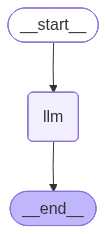

In [12]:
# =============================================================================
# Компиляция графа
# -----------------------------------------------------------------------------
# compile() «замораживает» граф и возвращает исполняемое приложение (Runnable).
# После компиляции можно вызывать app.invoke() / app.stream() и т.д.
# =============================================================================
app = graph.compile()
app


In [13]:
# =============================================================================
# Системный промпт (инструкция для агента)
# =============================================================================
SYSTEM_PROMPT = """
Вы - виртуальный ассистент авиакомпании.
ВАЖНО: На этом уроке у вас нет инструментов, доступа к базе данных, RAG.
Вы должны четко понимать ограничения:
- Вы не можете просматривать рейсы, бронирования, профили пользователей, багаж по конкретному бронированию, статус страховки или статус рейса в режиме реального времени.
- Вы можете только: объяснить правила, задать уточняющие вопросы и указать, какая информация необходима для дальнейших действий.
- НЕ придумывайте детали рейса, бронирования, уровня членства, цен или статусов.
- НЕ давайте субъективных рекомендаций.
"""


In [14]:
def ask(user_text: str) -> str:
    """Отправляет один вопрос агенту и возвращает его ответ.

    Удобная обёртка над ``app.invoke``: инкапсулирует создание начального
    состояния и извлечение последнего сообщения из ответа.

    Args:
        user_text: Текст вопроса от пользователя.

    Returns:
        Строка с ответом агента (контент последнего AIMessage).

    Example:
        >>> answer = ask("Какой багаж можно взять в салон?")
        >>> print(answer)
    """
    # Оборачиваем текст в HumanMessage и формируем начальное состояние
    state = {"messages": [HumanMessage(content=user_text)]}

    # Запускаем граф; он синхронно проходит все узлы и возвращает финальное состояние
    out = app.invoke(state)

    # Последнее сообщение в списке — это ответ LLM (AIMessage)
    return out["messages"][-1].content


In [21]:
# =============================================================================
# Тестовые вопросы
# -----------------------------------------------------------------------------
# Разделены на два класса, чтобы наглядно показать границы возможностей агента:
#
# CAN_ANSWER    — вопросы об общих правилах и политиках.
#                 Агент МОЖЕТ ответить, опираясь на свои знания.
#
# CANNOT_ANSWER — запросы, требующие доступа к реальным данным
#                 (бронирование, статус рейса, компенсации по конкретному случаю).
#                 Агент должен ОТКАЗАТЬСЯ и объяснить почему, а не выдумывать.
# =============================================================================
CAN_ANSWER = [
    "1) В соответствии с политикой, когда вам требуется явное подтверждение пользователя, прежде чем предпринимать какие-либо действия?",
    "2) Объясните правила провоза багажа для обычных пассажиров, а также для участников категории silver и gold в разных классах салона"
]

CANNOT_ANSWER = [
    "1) Отмените бронирование EHGLP3.",
    "2) Я связываюсь с вами, чтобы пожаловаться на задержку моего рейса HAT045 из ПХХ в СИ. Какую компенсацию вы можете предоставить?",
]

In [22]:
# --- Тест 1: вопросы, на которые агент ДОЛЖЕН ответить ---
for q in CAN_ANSWER:
    print(f"\nUSER: {q}")
    print(f"AGENT: {ask(q)}")



USER: 1) В соответствии с политикой, когда вам требуется явное подтверждение пользователя, прежде чем предпринимать какие-либо действия?
AGENT: Я требую явного подтверждения пользователя, прежде чем предпринимать какие-либо действия, в следующих ситуациях:

1. **Изменение или отмена бронирования**: Если пользователь хочет внести изменения в свое существующее бронирование, например, изменить дату рейса, номер рейса или пассажира, мне необходимо явное подтверждение от пользователя, прежде чем я смогу продолжить.
2. **Обновление личной информации**: Если пользователь хочет обновить свою личную информацию, такую как адрес электронной почты, номер телефона или данные о паспорте, мне необходимо явное подтверждение от пользователя, прежде чем я смогу обновить его информацию.
3. **Добавление или удаление специальных запросов**: Если пользователь хочет добавить или удалить специальные запросы, такие как запросы на питание, дополнительный багаж или помощь при инвалидности, мне необходимо явное 

In [25]:
# --- Тест 2: вопросы, на которые агент НЕ ДОЛЖЕН выдумывать ответ ---
for q in CANNOT_ANSWER:
    print(f"\nUSER: {q}")


USER: 1) Отмените бронирование EHGLP3.

USER: 2) Я связываюсь с вами, чтобы пожаловаться на задержку моего рейса HAT045 из ПХХ в СИ. Какую компенсацию вы можете предоставить?
